## Reproductible fitting for the `jmstate` package

In [1]:
%pip install jmstate==0.11.0 pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import torch

In [3]:
torch.manual_seed(42)


TAU = 7.5


def reg(t: torch.Tensor, psi: torch.Tensor):
    b, w1, w2 = psi.chunk(3, dim=-1)  # Extract relevant terms

    # psi has shape (n_chains, n_individuals, n_repetitions)
    return (b + w1 * t + (w2 - w1) * (t > TAU) * (t - TAU)).unsqueeze(-1)


def link(t: torch.Tensor, psi: torch.Tensor):
    b, w1, w2 = psi.chunk(3, dim=-1)

    diff = (w2 - w1) * (t > TAU)
    val = b + w1 * t + diff * (t - TAU)
    der = w1 + diff
    return torch.cat([val.unsqueeze(-1), der.unsqueeze(-1)], dim=-1)


def random_far_apart(
    n: int, m: int, a: torch.Tensor, b: torch.Tensor, min_dist: torch.Tensor
):
    L_free = (b - a) - (m - 1) * min_dist

    y = torch.rand(n, m) * L_free
    y, _ = torch.sort(y, dim=1)

    gap_offset = torch.arange(m) * min_dist

    return a + y + gap_offset

In [4]:
from jmstate.functions.base_hazards import Exponential
from jmstate.functions.individual_effects import gamma_plus_b
from jmstate.types import ModelDesign

# Survival model specification
surv = {
    (0, 1): (Exponential(1e-3), link),
    (0, 2): (Exponential(1e-4), link),
    (1, 2): (Exponential(1e-4), link),
}

# Model design gathers regression, link and hazard functions
model_design = ModelDesign(gamma_plus_b, reg, surv)

In [5]:
from jmstate.types import CovParameters, ModelParameters

# Gaussian means
gamma = torch.tensor([2.5, -1.3, 0.2])

# Covariance matrices
Q = torch.diag(torch.tensor([0.6, 0.2, 0.3]))
R = torch.tensor([[1.7]])

# Link parameters
alphas = {
    (0, 1): torch.tensor([-0.5, -1.0]),
    (0, 2): torch.tensor([-1.0, -0.5]),
    (1, 2): torch.tensor([-1.0, 0.0]),
}

# Covariate parameters
betas = {
    (0, 1): torch.tensor([-1.3]),
    (0, 2): torch.tensor([-0.9]),
    (1, 2): torch.tensor([-0.7]),
}

# Instance declaration
true_parameters = ModelParameters(
    gamma,
    CovParameters.from_cov(Q, covariance_type="diag"),
    CovParameters.from_cov(R, covariance_type="spherical"),
    alphas,
    betas,
)


In [6]:
from jmstate import MultiStateJointModel
from jmstate.types import ModelData, SampleData
from torch.distributions import MultivariateNormal

# Declare the true underlying model
true_model = MultiStateJointModel(model_design, true_parameters)


def gen_data(n: int, m: int):
    # Censoring times
    c = torch.rand(n, 1) * 5 + 10

    # Covariates
    x = torch.randn(n, 1)

    # Latent and noise distributions
    Q_dist = MultivariateNormal(torch.zeros(Q.size(0)), Q)
    R_dist = MultivariateNormal(torch.zeros(R.size(0)), R)

    # Individual effects
    b = Q_dist.sample((n,))
    psi = model_design.individual_effects_fn(gamma, x, b)

    # Generates random evaluations points with a minimum distance
    a = torch.zeros((n, 1))
    b = torch.full((n, 1), 15)
    t = random_far_apart(n, m, a, b, 0.7 * b / m)

    # Defines initial state for individuals
    trajectories_init = [[(0.0, 0)] for _ in range(n)]

    # Samples trajectories
    sample_data = SampleData(x, trajectories_init, psi)
    trajectories = true_model.sample_trajectories(sample_data, c)

    # Samples longitudinal values
    y = model_design.regression_fn(t, psi)
    y += R_dist.sample(y.shape[:2])

    # Censors longitudinal measurements exceeding censoring times
    y[t > c] = torch.nan

    return x, t, y, trajectories, c


data = ModelData(*gen_data(1000, 20))

In [7]:
from jmstate.utils import build_buckets

buckets = build_buckets(data.trajectories)
print({key: val.idxs.numel() for key, val in buckets.items()})


{(0, 1): 300, (0, 2): 316, (1, 2): 216}


In [8]:
# Declares initial parameters; zero mean and unit variance
def init_params():
    return ModelParameters(
        torch.zeros_like(gamma),
        CovParameters.from_cov(torch.eye(Q.size(0)), "diag"),
        CovParameters.from_cov(torch.eye(R.size(0)), "spherical"),
        {k: torch.zeros_like(v) for k, v in alphas.items()},
        {k: torch.zeros_like(v) for k, v in betas.items()},
    )


def init_params_shared():
    alpha_shared = torch.zeros(2)

    return ModelParameters(
        torch.zeros_like(gamma),
        CovParameters.from_cov(torch.eye(Q.size(0)), "diag"),
        CovParameters.from_cov(torch.eye(R.size(0)), "spherical"),
        {k: alpha_shared for k, v in alphas.items()},
        {k: torch.zeros_like(v) for k, v in betas.items()},
    )


def init_params_full():
    return ModelParameters(
        torch.zeros_like(gamma),
        CovParameters.from_cov(torch.eye(Q.size(0)), "full"),
        CovParameters.from_cov(torch.eye(R.size(0)), "spherical"),
        {k: torch.zeros_like(v) for k, v in alphas.items()},
        {k: torch.zeros_like(v) for k, v in betas.items()},
    )


In [12]:
from jmstate.utils import summary

# Declares initial model
params = init_params()
optimizer = torch.optim.Adam(params.parameters(), lr=0.5, amsgrad=True)
model = MultiStateJointModel(model_design, params, optimizer)

# Runs optimization process
model.fit(data)

# Prints relevant information
summary(model)

Computing FIM and Model Selection Criteria: 100%|██████████| 100/100 [00:21<00:00,  4.59it/s]


╭───────────────────────────────────── Model Summary ─────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓ │
│ ┃ Parameter name   ┃ Value  ┃ Standard Error ┃ z-value ┃ p-value ┃ Significance level ┃ │
│ ┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩ │
│ │ gamma[0]         │ 2.540  │     0.034      │ 74.281  │  0.000  │        ***         │ │
│ │ gamma[1]         │ -1.287 │     0.015      │ 85.966  │  0.000  │        ***         │ │
│ │ gamma[2]         │ 0.199  │     0.019      │ 10.594  │  0.000  │        ***         │ │
│ │ q.flat[0]        │ 0.266  │     0.044      │  6.054  │  0.000  │        ***         │ │
│ │ q.flat[1]        │ 0.770  │     0.023      │ 33.426  │  0.000  │        ***         │ │
│ │ q.flat[2]        │ 0.643  │     0.029      │ 22.539  │  0.000  │        ***         │ │
│ │ r.flat[0]        │ -0.272 │     0.006      │ 47.187  │  0.000  │        ***         │ │
│ │ alphas.(0, 1)[0] │ -0.488 │     0.021      │ 23.369  │  0.000  │        ***         │ │
│ │ alphas.(0, 1)[1] │ -0.950 │     0.084      │ 11.287  │  0.000  │        ***         │ │
│ │ alphas.(0, 2)[0] │ -1.041 │     0.012      │ 84.758  │  0.000  │        ***         │ │
│ │ alphas.(0, 2)[1] │ -0.311 │     0.066      │  4.696  │  0.000  │        ***         │ │
│ │ alphas.(1, 2)[0] │ -1.001 │     0.020      │ 50.308  │  0.000  │        ***         │ │
│ │ alphas.(1, 2)[1] │ -0.194 │     0.107      │  1.809  │  0.070  │         .          │ │
│ │ betas.(0, 1)[0]  │ -1.266 │     0.073      │ 17.325  │  0.000  │        ***         │ │
│ │ betas.(0, 2)[0]  │ -0.964 │     0.064      │ 15.042  │  0.000  │        ***         │ │
│ │ betas.(1, 2)[0]  │ -0.711 │     0.093      │  7.643  │  0.000  │        ***         │ │
│ └──────────────────┴────────┴────────────────┴─────────┴─────────┴────────────────────┘ │
│ ─────────────────────────────────────────────────────────────────────────────────────── │
│ Log-likelihood: -33264.411                                                              │
│ AIC: 66560.822                                                                          │
│ BIC: 66641.972                                                                          │
│ ─────────────────────────────────────────────────────────────────────────────────────── │
╰─────────────────────────────────────────────────────────────────────────────────────────╯

In [19]:
import dataclasses

@dataclasses.dataclass
class ModelSelectionResults:
    def __post_init__(self):
        print("results")

@dataclasses.dataclass
class ModelSelectionResults2:
    def __post_init__(self):
        print("no")

t = ModelSelectionResults2()

no


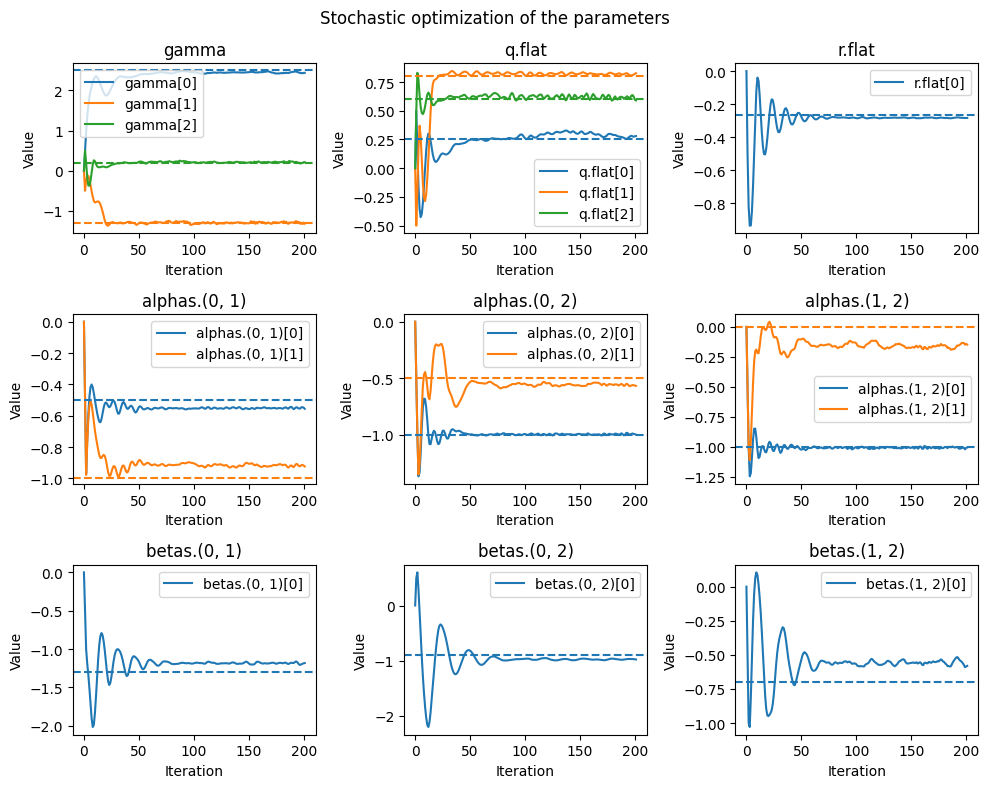

In [10]:
from jmstate.utils import plot_params_history

fig, axes = plot_params_history(model)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for ax, param in zip(list(axes), true_parameters.parameters(), strict=False):
    for i, p in enumerate(param):
        ax.axhline(y=p.detach(), c=colors[i], linestyle="--")
plt.show()

In [11]:
from torch.nn.utils import parameters_to_vector
from tqdm import trange


def get_vector_and_scores(parameters_factory, data):
    parameters = parameters_factory()
    optimizer = torch.optim.Adam(parameters.parameters(), lr=0.5, amsgrad=True)
    model = MultiStateJointModel(
        model_design, parameters, optimizer, verbose=False
    ).fit(data)

    return parameters_to_vector(model.parameters()), model.aic_, model.bic_


# Define competing models
parameters_factories = [init_params, init_params_shared, init_params_full]
n_redo = 1

# Storage for results
all_results = {i: [] for i in range(len(parameters_factories))}

for _ in trange(n_redo):
    # Generate new data for this redo
    data = ModelData(*gen_data(1000, 20))

    for i, factory in enumerate(parameters_factories):
        vector, aic, bic = get_vector_and_scores(factory, data)
        all_results[i].append({"vector": vector, "aic": aic, "bic": bic})

# Extract AICs and BICs for analysis
aics = {i: [r["aic"] for r in all_results[i]] for i in range(len(parameters_factories))}
bics = {i: [r["bic"] for r in all_results[i]] for i in range(len(parameters_factories))}

print("AICs across redos:", aics)
print("BICs across redos:", bics)


  0%|          | 0/1 [00:35<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
names = list(true_parameters.as_dict.keys())

stacked_params = torch.cat(params_list, dim=0)
mean = stacked_params.mean(dim=0)
std = stacked_params.std(dim=0)
rmse = (std**2 + (mean - true_model.params_.as_flat_tensor) ** 2).sqrt()

data = {
    "True value": true_model.params_.as_flat_tensor.numpy(),
    "Mean": mean.numpy(),
    "Std error": std.numpy(),
    "RMSE": rmse.numpy(),
}

index = [
    f"{names[i]}[{j}]" if true_parameters.as_list[i].numel() > 1 else f"{names[i]}"
    for i in range(len(names))
    for j in range(true_parameters.as_list[i].numel())
]


df = pd.DataFrame(data, index=index)
pd.set_option("display.float_format", "{:.4e}".format)

print(df)

AttributeError: 'ModelParameters' object has no attribute 'as_dict'